# BME-336546-C07-Unsupervised learning - Clustering (k-means and GMM)
Start by updating your venv with `tutorial8.yml`.

## Main ML topic:
Unsuprvised learning. Our data is not labeld so we try to cluster our examples according to their features distribution.

## Our mission
Clustering our data "correctly" with no prior knowladge.

## Theory reminders
### k-means
*k-means* is a method that tries to estimate the centroids of the unknown $K$ clusters when $K$ is given to us. This algorithm is an iterative algorithm that starts with random centroids and updates them by the assignment of the data to the cluster. The data points are assigned to a cluster by searching the minimal "distance" between each data point to the centroid using some distance measure $d(x,\mu)$. 


The formalized algorithm is as follows:
1. Set the number of clusters ($K$), number of iterations ($N$) and a distance measure $d(\bullet,\bullet)$.
2. Scale your data $D=\{x^{(1)},\dots,x^{(m)}\} \in \mathbb{R}^n$.
3. Intialize $\{\mu_1,\dots,\mu_K\}$.
4. $ \forall i, C_i = \{x \in D, i=\underset{j}{argmin} \space d(x,\mu_j)\} $
5. $ \forall i, \mu_i= \underset{\mu}{argmin}\sum_{x\in C_i}{}d(x,\mu) $
6. Repeat (4)-(5) $N$ times.


Note the following:
* k-means is sensitive to scaling.
* It is highly depended on intializations and the number $K$.
* A different distance measure would result in different clustering.
* This is a "hard clustering" method, meaning a data point either belongs to a cluster $C_i$ or it does not. 

We can visualize this process [here](https://stanford.edu/class/engr108/visualizations/kmeans/kmeans.html).

### Gaussian mixture models
In Gaussian mixture models (GMM), we assume that our data was drawn from different clusters where each of them is Gaussian distributed. Our aim is actually to estimate the deterministic parameters of theses distributions (expected values, $\mu_z$, and covariance matrices, $\Sigma_z$) and cluster probabilities, $\pi_z$. In order to do so, we would use the maximum likelihood estimation (MLE). Thus, We would like to maximize the likelihood term:
$$\begin{equation}
L(\pi,\mu,\Sigma)=\prod_{i=1}^mp(x^{(i)})=\prod_{i=1}^m\sum_{z=1}^{K}\mathcal{N}(x^{(i)}|\mu_z,\Sigma_z)\pi_z
\end{equation}$$
We maximize this term by using an iterative algorithm that updates the initialized parameters that in their turn, update the *responsibility term* ($\gamma$) which in its' turn updates the parameters and so on and so forth. The mentioned terms are calculated as follows:
$$\begin{equation}
\gamma_i^c=\frac{\mathcal{N}(x^{(i)}|\mu_c,\Sigma_c)\pi_c}{\sum_{z=1}^K\mathcal{N}(x^{(i)}|\mu_z,\Sigma_z)\pi_z}
\tag{1}
\end{equation}$$
$$\begin{equation}
m_c=\sum_{i=1}^{m}\gamma_i^c
\tag{2}
\end{equation}$$
$$\begin{equation}
\mu_c=\frac{1}{m_c}\sum_{i=1}^{m}\gamma_i^cx^{(i)}
\tag{3}
\end{equation}$$
$$\begin{equation}
\Sigma_c=\frac{1}{m_c}\sum_{i=1}^{m}\gamma_i^c(x^{(i)} - \mu_c)(x^{(i)} - \mu_c)^T
\tag{4}
\end{equation}$$
$$\begin{equation}
\pi_c = \frac{m_c}{m}
\tag{5}
\end{equation}$$
The responsabilities represent the probability of an example to belong to some cluster given the values of the example's features i.e.
$$\begin{equation}
\gamma_i^c=\overbrace{P(Z=c|X=x^{(i)})}^{A posterior}\overset{Bayes}{=}\frac{\overbrace{P(X=x^{(i)}|Z=c)}^{Likelihood}\overbrace{P(Z=c)}^{Prior}}{\underbrace{P(X=x^{(i)})}_{Evidence}}
\end{equation}$$
Thus, the vector $(\gamma_i^1,\dots \gamma_i^K)$ is a *soft* assignment of $x^{(i)}$ in contrary to k-means. This means that GMM does not really assign an example to a single cluster but rather calculates the probability to belong to each cluster. In this aspect, the comparison of k-means vs. GMM is analogous to SVM vs. logistic regression respectively. 

We can visualize this process [here](https://lukapopijac.github.io/gaussian-mixture-model/).


### K evaluation
An important topic in clustering algorithms is choosing $K$. Two methods to choose $K$ that are complementary to each other are the *elbow curve* and *Silhouette Curve*. The first one computes the sum of squered errors $(SSE)$ as function of $K$ as it tries to capture how spreaded the data points are around the adequate centroids once the algorithm converged. The $K$ that creates an "elbow" is chosen. $SSE$ is computed as follows:
$$\begin{equation}
SSE(K)=\sum_{k=1}^{K}\sum_{x \in C_k}{}d(x,\mu_k)^2
\end{equation}$$


The *Silhouette coefficient* is a measure of how tightly grouped all the points in the cluster are. Thus, it is a measure of how appropriately the data have been clustered. Let us define our $i^{th}$ example of our dataset assigned to $C_k$ as $x_{ik}$.

We start by estimating the mean distance of $x_{ik}$ to it's neighbors within the same cluster:
$$\begin{equation}
a(x_{ik})=\frac{1}{|C_i|-1}\sum_{x_{jk}, i \neq j}{}d(x_{ik},x_{jk})
\end{equation}$$
We then define the mean dissimilarity of point $x_{ik}$ to some **other** cluster $C_n$ as the mean of the distance from $x_{ik}$ to all points in $C_n$. 

$b(x_{ik})$ is the mean distance of the "closest" cluster.
$$\begin{equation}
b(x_{ik})=\underset{n \neq k}{\min}\frac{1}{|C_n|}\sum_{x_{jn}}{}d(x_{ik},x_{jn})
\end{equation}$$
The *Silhouette coefficient* is calculated as:
$$\begin{equation}
s(x_{ik})=\frac{b(x_{ik})-a(x_{ik})}{\max\{a(x_{ik}),b(x_{ik})\}},-1\leq s(x_{ik}) \leq 1
\end{equation}$$
The closer the coefficient is to 1, the better the assignment of the example is. The closer the coefficient is to -1, the better the assignment of the example would have been to the neighboring clusetr.

The *Silhouette score* is calculated as:
$$\begin{equation}
S_c(K)=\underset{k}{\max}\frac{1}{|C_k|}\sum_{x_{ik}}{}s(x_{ik})
\end{equation}$$

## Data loading

In [1]:
import numpy as np
import itertools
from tqdm import tqdm
from kneed import KneeLocator
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import pickle
import sys
import pandas as pd
import matplotlib as mpl
import seaborn as sns
import matplotlib.pyplot as plt
mpl.style.use(['ggplot']) 
%matplotlib inline
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.mixture import GaussianMixture
from sklearn.pipeline import Pipeline
from IPython.display import display, clear_output

We will start with generating our data, split it, scale it and plot it:

In [2]:
features, true_labels = make_blobs(n_samples=1000,centers=4,cluster_std=1.75,random_state=336543)
X_train_orig, X_test_orig, y_train, y_test = train_test_split(features,true_labels,test_size=0.2, random_state=336546)

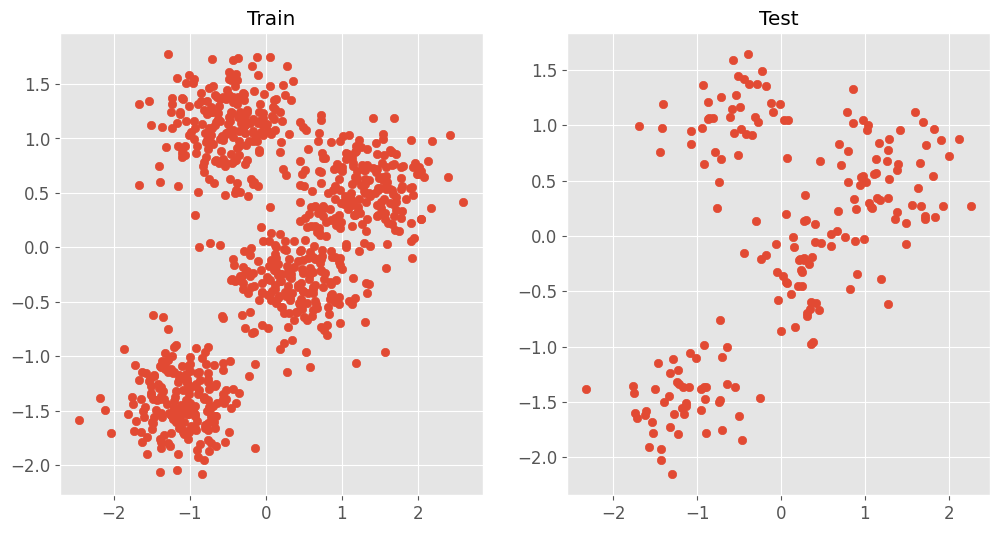

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_orig)
X_test = scaler.transform(X_test_orig)
fig, axs = plt.subplots(1, 2, figsize=(12,6))
for idx, ax in enumerate(axs.flatten()):
    if idx == 0:
        ax.scatter(X_train[:,0], X_train[:,1])
        ax.set_title('Train')
    else:
        ax.scatter(X_test[:,0], X_test[:,1])
        ax.set_title('Test')

---
This is the original data with no labels at all.

<span style="color:red">***Question:***</span> *How many clusters do you see?*

---

Let's see from how many distributions this data was drawn from:

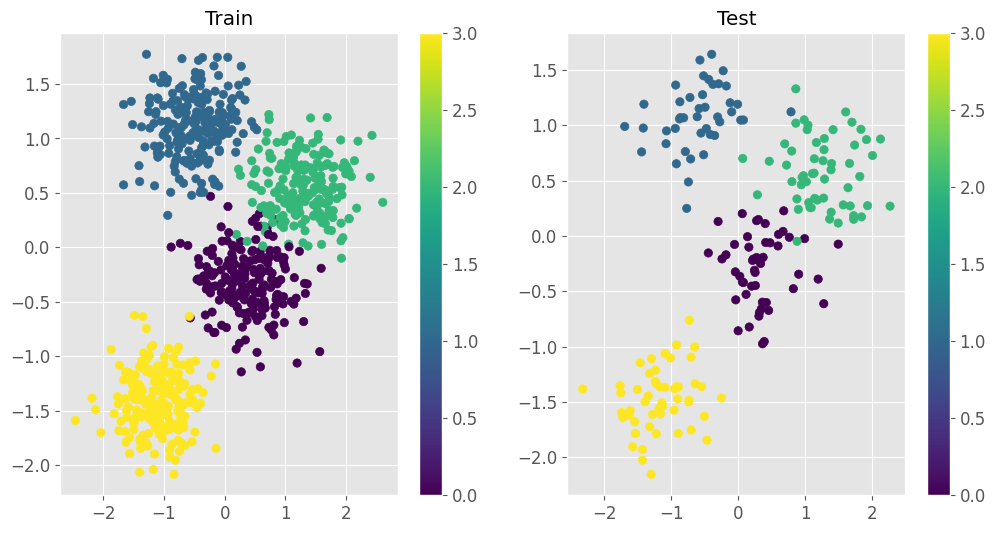

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(12,6))
for idx, ax in enumerate(axs.flatten()):
    if idx == 0:
        scatter = ax.scatter(X_train[:,0], X_train[:,1], c=y_train, cmap='viridis')
        ax.set_title('Train')
        plt.colorbar(scatter, ax=ax)
    else:
        scatter = ax.scatter(X_test[:,0], X_test[:,1], c=y_test, cmap='viridis')
        ax.set_title('Test')
        plt.colorbar(scatter, ax=ax)

Now you should implement *k-means* algorithm for the $L_2$ norm. `df` should containg the examples and thier assigned cluster. Notice that cluster numbers should range from 1:K and not from 0:K-1. Your implementation here is basically stage (4) of the algorithm.

In [9]:
# C1
def k_means(mu,x_train):
    K = mu.shape[0]
    df = pd.DataFrame(columns=['x_i','C_i'])
    n_iter = 10
    with tqdm(total=n_iter, file=sys.stdout) as pbar:
        for i in range(n_iter):
            pbar.set_description('processed: %d/%d' % ((1 + i), n_iter))
            pbar.update(1)
            for idx_row in range(x_train.shape[0]):
            #---------------------------------------------------------------------------
                distances = []
                for idx, m in enumerate(mu):
                #---------------------------------------------------------------------
                    # Calculate L2 distance (Euclidean distance)
                    dist = np.linalg.norm(x_train[idx_row] - m)
                    distances.append(dist)

                #--------------------------------------------------------------------
                # Find closest cluster (add 1 because clusters should range from 1 to K)
                closest_cluster = np.argmin(distances) + 1
                df = pd.concat([df, pd.DataFrame({'x_i': [x_train[idx_row]], 'C_i': [closest_cluster]})], ignore_index=True)

            #--------------------------------------------------------------------------
            mu = np.empty((0, 2))
            for k in range(K):
                mean_val = df['x_i'].loc[df.loc[:,'C_i']==k+1].values.mean(axis=0)
                mu = np.vstack([mu, mean_val])
            df = pd.DataFrame(columns=['x_i','C_i'])
    return mu, df

Let's intialize the centroids as follows ($K=2$):

In [10]:
init_mu = np.array([[0 ,0], [-0.5, 1]])
mu, cluster_df_train = k_means(init_mu,X_train)

processed: 10/10: 100%|██████████| 10/10 [00:02<00:00,  3.82it/s]


Now implement the clustering according to the learned centroids applied on the test set.

In [11]:
# C2
def test_cluster(mu,x_test):
    df = pd.DataFrame(columns=['x_i','C_i'])
    K = mu.shape[0] 
    for idx_row in range(x_test.shape[0]):
    #---------------------------------------------------------------------------
        distances = []
        for idx, m in enumerate(mu):
        #---------------------------------------------------------------------------
            # Calculate L2 distance
            dist = np.linalg.norm(x_test[idx_row] - m)
            distances.append(dist)

        #---------------------------------------------------------------------------
        # Find closest cluster (add 1 because clusters should range from 1 to K)
        closest_cluster = np.argmin(distances) + 1
        df = pd.concat([df, pd.DataFrame({'x_i': [x_test[idx_row]], 'C_i': [closest_cluster]})], ignore_index=True)

    #---------------------------------------------------------------------------
    return df

In [12]:
cluster_df_test = test_cluster(mu,X_test)

In [16]:
def plot_Kmeans(X_train,X_test,cluster_df_train,cluster_df_test,mu,init_mu):
    fig, axs = plt.subplots(1, 2, figsize=(12,6))
    for idx, ax in enumerate(axs.flatten()):
        if idx == 0:
            ax.scatter(X_train[:,0], X_train[:,1], c=cluster_df_train['C_i'], cmap='viridis')
            ax.plot(mu[:,0],mu[:,1],'b+', linewidth=2, markersize=20,markeredgewidth=4)
            ax.plot(init_mu[:,0],init_mu[:,1],'g+', linewidth=2, markersize=20,markeredgewidth=4)
            ax.legend(('new','init'))
            ax.set_title('Train')
        else:
            ax.scatter(X_test[:,0], X_test[:,1], c=cluster_df_test['C_i'], cmap='viridis')
            ax.plot(mu[:,0],mu[:,1],'b+', linewidth=2, markersize=20,markeredgewidth=4)
            ax.plot(init_mu[:,0],init_mu[:,1],'g+', linewidth=2, markersize=20,markeredgewidth=4)
            ax.legend(('new','init'))
            ax.set_title('Test')

C:\Users\Admin\AppData\Local\Temp\ipykernel_21320\2857234118.py:5: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(X_train[:,0], X_train[:,1], c=cluster_df_train['C_i'], cmap='viridis')


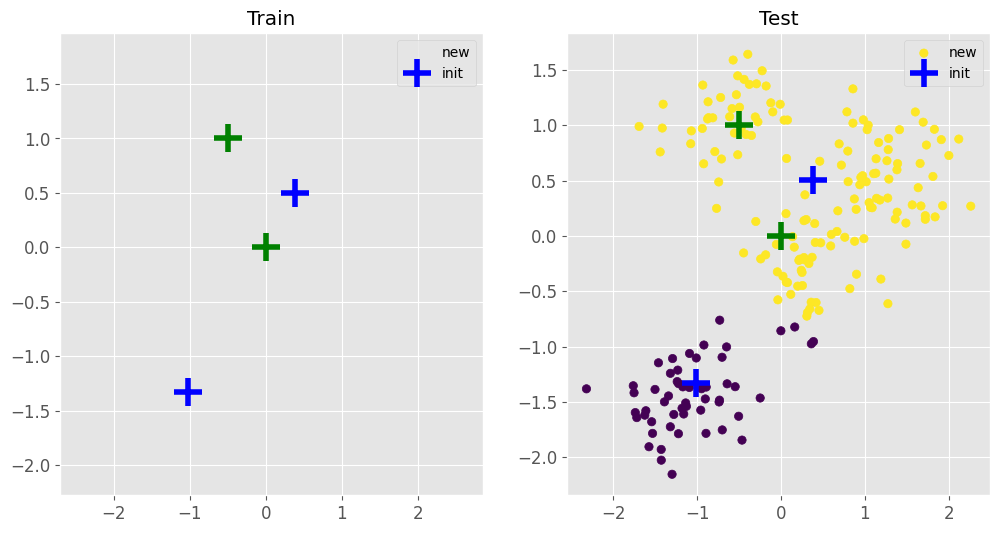

In [17]:
plot_Kmeans(X_train,X_test,cluster_df_train,cluster_df_test,mu,init_mu)

### Expected output:
<center><img src="outputs/1.PNG" width="480"><center>

Notice how the initial centroids have updated. Even though it is not the "correct" number of clusters, the algorithm still converged and had its' results. This shows us the significance of choosing $K$. Let's try 5 clusters and visualize how the centroids are updated.

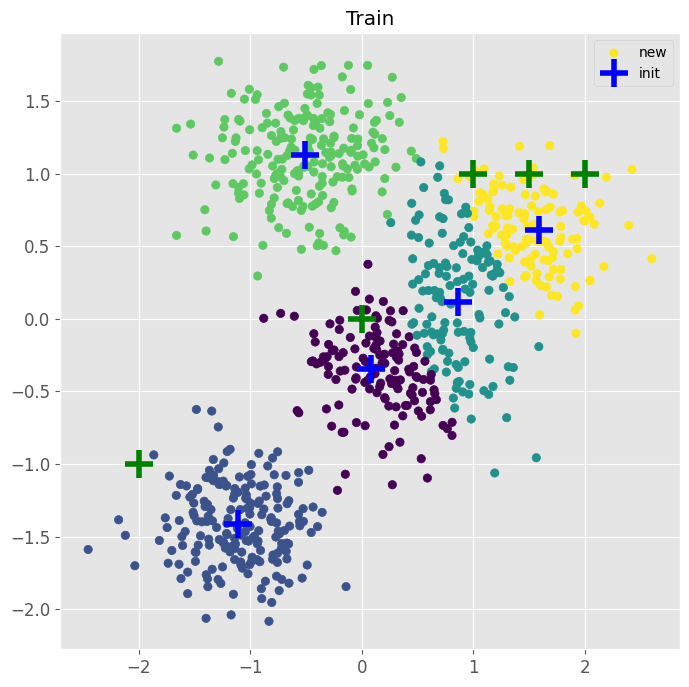

In [18]:
#C3
# Visualization of 5 clusters
init_mu = np.array([[0 ,0], [-2, -1], [1.5,1], [1,1], [2,1]])
mu = np.array([[0 ,0], [-2, -1], [1.5,1], [1,1], [2,1]])
K = mu.shape[0]

df = pd.DataFrame(columns=['x_i','C_i'])
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1)
n_iter = 6
for i in range(n_iter):
    for idx_row in range(X_train.shape[0]):
    #---------------------------------------------------------------------------
        distances = []
        for idx, m in enumerate(mu):
        #---------------------------------------------------------------------
            # Calculate L2 distance
            dist = np.linalg.norm(X_train[idx_row] - m)
            distances.append(dist)

        #--------------------------------------------------------------------
        # Find closest cluster
        closest_cluster = np.argmin(distances) + 1
        df = pd.concat([df, pd.DataFrame({'x_i': [X_train[idx_row]], 'C_i': [closest_cluster]})], ignore_index=True)

    #--------------------------------------------------------------------------
    ax.cla()
    ax.scatter(X_train[:,0], X_train[:,1], c=df['C_i'], cmap='viridis')
    print(mu)
    ax.plot(mu[:,0],mu[:,1],'b+', linewidth=2, markersize=20,markeredgewidth=4)
    ax.plot(init_mu[:,0],init_mu[:,1],'g+', linewidth=2, markersize=20,markeredgewidth=4)
    ax.set_title('Train')
    display(fig)
    clear_output(wait = True)
    plt.pause(1.2)
    mu = np.empty((0, 2))
    for k in range(K):
        mean_val = df['x_i'].loc[df.loc[:,'C_i']==k+1].values.mean(axis=0)
        mu = np.vstack([mu, mean_val])
    df = pd.DataFrame(columns=['x_i','C_i'])
ax.legend(('new','init'))
display(fig)

### Expected output:
<center><img src="outputs/2.PNG" width="480"><center>

In order to see the effect of intialization, try the following centroids:

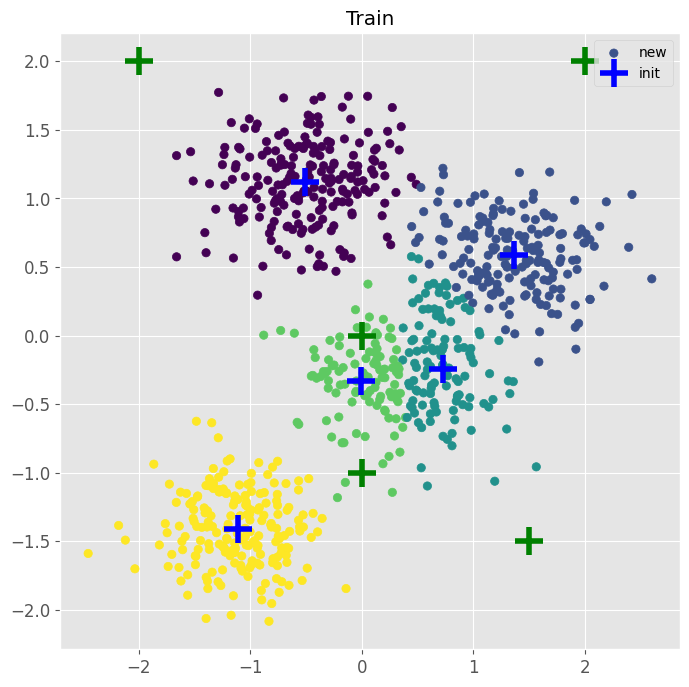

In [19]:
#C4
# Visualization of 5 clusters with different initial weights
init_mu = np.array([[-2 ,2], [2, 2], [1.5,-1.5], [0,0], [0,-1]])
mu = np.array([[-2 ,2], [2, 2], [1.5,-1.5], [0,0], [0,-1]])
K = mu.shape[0]
df = pd.DataFrame(columns=['x_i','C_i'])
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1)
n_iter = 10
for i in range(n_iter):
    for idx_row in range(X_train.shape[0]):
    #---------------------------------------------------------------------------
        distances = []
        for idx, m in enumerate(mu):
        #---------------------------------------------------------------------
            # Calculate L2 distance
            dist = np.linalg.norm(X_train[idx_row] - m)
            distances.append(dist)

        #--------------------------------------------------------------------
        # Find closest cluster
        closest_cluster = np.argmin(distances) + 1
        df = pd.concat([df, pd.DataFrame({'x_i': [X_train[idx_row]], 'C_i': [closest_cluster]})], ignore_index=True)

    #--------------------------------------------------------------------------
    ax.cla()
    ax.scatter(X_train[:,0], X_train[:,1], c=df['C_i'], cmap='viridis')
    ax.plot(mu[:,0],mu[:,1],'b+', linewidth=2, markersize=20,markeredgewidth=4)
    ax.plot(init_mu[:,0],init_mu[:,1],'g+', linewidth=2, markersize=20,markeredgewidth=4)
    ax.set_title('Train')
    display(fig)
    clear_output(wait = True)
    plt.pause(1.2)
    mu = np.empty((0, 2))
    for k in range(K):
        mean_val = df['x_i'].loc[df.loc[:,'C_i']==k+1].values.mean(axis=0)
        mu = np.vstack([mu, mean_val])
    df = pd.DataFrame(columns=['x_i','C_i'])
ax.legend(('new','init'))
display(fig)

### Expected output:
<center><img src="outputs/3.PNG" width="480"><center>

---

<span style="color:red">***Question:***</span> *Did you get any different results?*

---

`scikit-learn` has of course its' own implemetation. Notice that the k-means algorithm is very fast but tends to falls in local minima. Thus, it can be useful to restart it several times. We do it with `n_init` key-value argument. In addition, we can pick "smart" initializations using `init:k-means++`. Build a dictionary with smart initialization, 10 "runs", random state of 336546 and maximum iterations of 10. Then use a for loop that runs $K$ from 1 to 10 and saves the SSE for every cluseter (notice `inertia_` attribute in `KMeans`).

In [20]:
#C5
sse = []
#---------------------------------------------------------------------------
for K in range(1, 11):
    kmeans = KMeans(init="k-means++", n_clusters=K, n_init=10, max_iter=10, random_state=336546)
    kmeans.fit(X_train)
    sse.append(kmeans.inertia_)

#---------------------------------------------------------------------------

Now we will plot the results and look for an "elbow".

---

<span style="color:red">***Question:***</span> *Where do you expect to have the elbow at?*

---

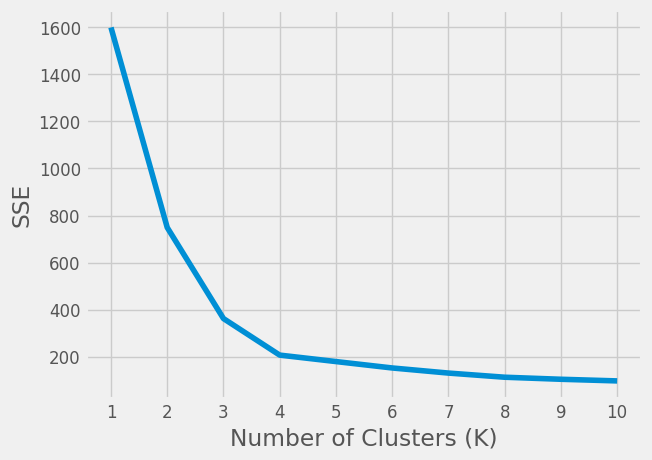

In [21]:
plt.style.use("fivethirtyeight")
plt.plot(range(1, 11), sse)
plt.xticks(range(1, 11))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("SSE")
plt.show()

### Expected output:
<center><img src="outputs/4.PNG" width="480"><center>

Surprisingly (or not), the elbow is found at $K=3$. Sometimes, it would be a bit difficult to see that so we can calculate it using `KneeLoacator` as follows:

In [22]:
kl = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing")
kl.elbow

np.int64(3)

Now, let's plot the silhouette_coefficients using silhouette_score (that was already imported) as a function of number of clusters.

In [23]:
#C6
silhouette_coefficients = []
# Notice you start at 2 clusters for silhouette coefficient
#---------------------------------------------------------------------------
for K in range(2, 11):
    kmeans = KMeans(init="k-means++", n_clusters=K, n_init=10, max_iter=10, random_state=336546)
    kmeans.fit(X_train)
    silhouette_coefficients.append(silhouette_score(X_train, kmeans.labels_))

#---------------------------------------------------------------------------

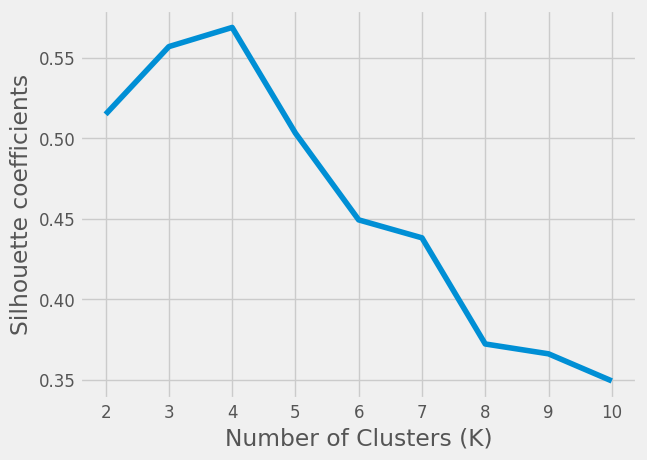

In [24]:
plt.plot(range(2, 11), silhouette_coefficients)
plt.xticks(range(2, 11))
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette coefficients")
plt.show()

### Expected output:
<center><img src="outputs/5.PNG" width="480"><center>

Here, the "correct" number is 4. This shows us how inconclusive the results can be. Here are some more methods and attributes that you can apply with `KMeans`.

SSE value is 206.10
Cluster centers are: [[-1.10453811 -1.40437362]
 [ 1.32919086  0.55462967]
 [-0.51012362  1.11031474]
 [ 0.36482081 -0.30957048]]
Number of iterations needed for convergence is: 3
[-1.10453811  1.32919086 -0.51012362  0.36482081]


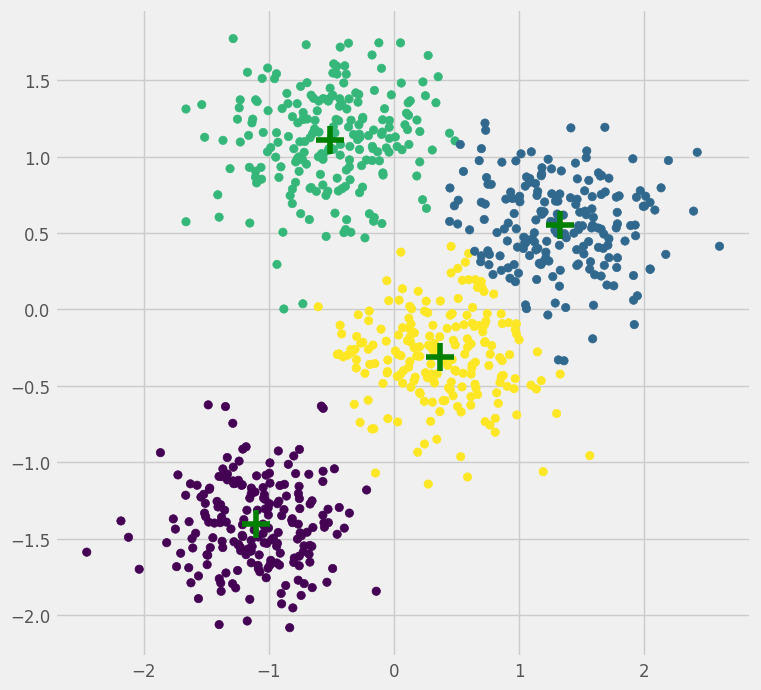

In [27]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(1, 1, 1)
kmeans = KMeans(init="k-means++", n_clusters=4, n_init=10, max_iter=10, random_state=336546)
kmeans.fit(X_train)  # predict labels 
ax.plot(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],'g+', linewidth=2, markersize=20,markeredgewidth=4)
ax.scatter(X_train[:,0], X_train[:,1], c=kmeans.predict(X_train), cmap='viridis')

print('SSE value is {:.2f}'.format(kmeans.inertia_))
print('Cluster centers are: {}'.format(kmeans.cluster_centers_))
print('Number of iterations needed for convergence is: {}'.format(kmeans.n_iter_))
print(kmeans.cluster_centers_[:,0])

Finally, let's compare GMM and k-means. Below, you have a function that plots Gaussian contours (based on elipsoid's principle axes) and k-means centroids. Use`pred_c_kmeans` and `pred_c_GMM` for predictions of the algorithms. Compare the results for $K=2,3,4$.

In [28]:
#C7
K = 4
# k-means
kmeans = KMeans(init="k-means++",n_clusters=K,n_init=10,max_iter=10,random_state=336546)
kmeans.fit(X_train)# predict labels 
pred_c_kmeans = kmeans.predict(X_train)
# GMM
GMM = GaussianMixture(n_components=K)
GMM.fit(X_train)
pred_c_GMM = GMM.predict(X_train)

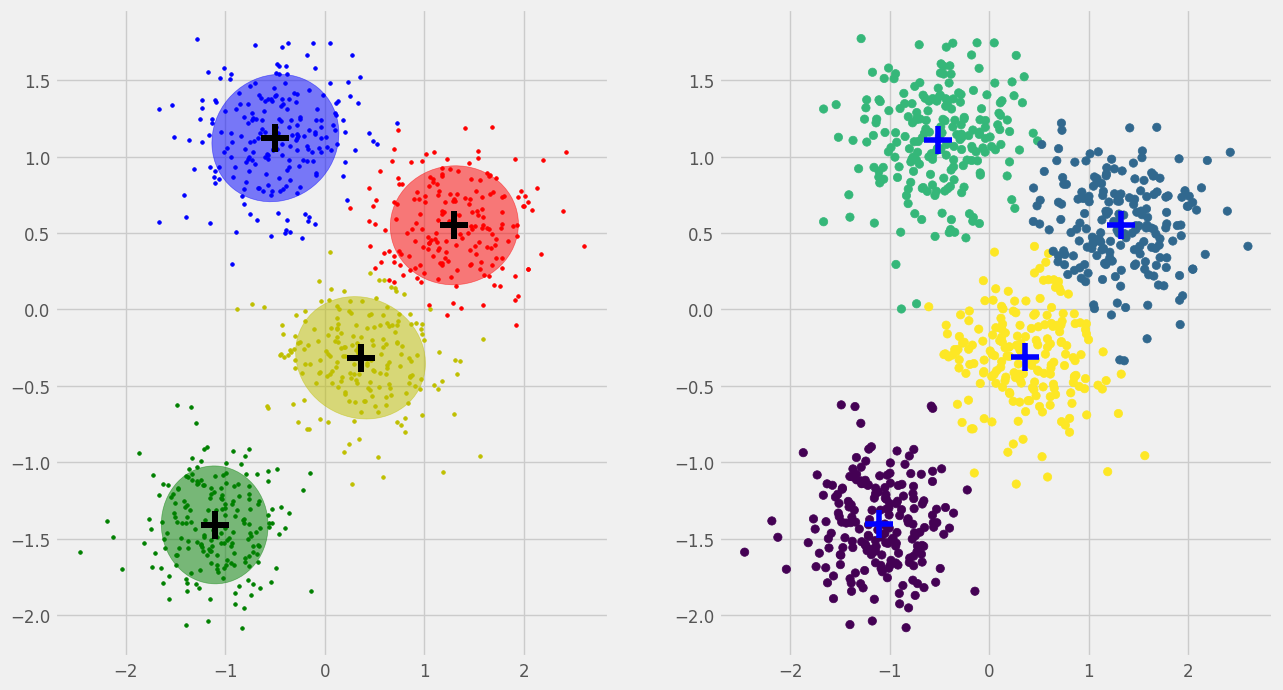

In [30]:
color_iter = itertools.cycle(['r', 'g', 'b', 'y'])
fig, axs = plt.subplots(1, 2, figsize=(14,8))
axs = axs.flatten()
for i, (mean, covar, color) in enumerate(zip(
        GMM.means_, GMM.covariances_, color_iter)):
    v, w = np.linalg.eigh(covar)
    v = 2. * np.sqrt(2.) * np.sqrt(v)
    u = w[0] / np.linalg.norm(w[0])
    # as the DP will not use every component it has access to
    # unless it needs it, we shouldn't plot the redundant
    # components.
    if not np.any(pred_c_GMM == i):
        continue
    axs[0].scatter(X_train[pred_c_GMM == i, 0], X_train[pred_c_GMM == i, 1], 7, color=color)
    axs[0].plot(GMM.means_[:,0],GMM.means_[:,1],'k+', linewidth=2, markersize=20,markeredgewidth=4)

    # Plot an ellipse to show the Gaussian component
    angle = np.arctan(u[1] / u[0])
    angle = 180. * angle / np.pi  # convert to degrees
    ell = mpl.patches.Ellipse(mean, v[0], v[1], angle=180. + angle, color=color)
    ell.set_alpha(0.5)
    axs[0].add_artist(ell)

axs[1].scatter(X_train[:,0], X_train[:,1], c=pred_c_kmeans, cmap='viridis')
axs[1].plot(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],'b+', linewidth=2, markersize=20,markeredgewidth=4)
plt.show()

#### *This tutorial was written by [Moran Davoodi](mailto:morandavoodi@gmail.com) with the assitance of [Yuval Ben Sason](mailto:yuvalbse@gmail.com) & Kevin Kotzen*